<a href="https://colab.research.google.com/github/joysujeeth1761/Salary-prediction-with-experience-years/blob/main/LINEARA_REGRESSION_PROJECT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [9]:
import kagglehub
import os

# Download latest version
ds_path = kagglehub.dataset_download("shubham47/salary-data-dataset-for-linear-regression")

print("Path to dataset files:", ds_path)

Using Colab cache for faster access to the 'salary-data-dataset-for-linear-regression' dataset.
Path to dataset files: /kaggle/input/salary-data-dataset-for-linear-regression


In [11]:
csv_files = [f for f in os.listdir(ds_path) if f.endswith('.csv')]
if not csv_files:
    raise FileNotFoundError(f"No CSV files found in {ds_path}")

data_filepath = os.path.join(ds_path, csv_files[0])
df = pd.read_csv(data_filepath)

print("Dataset loaded successfully. Head of the dataframe:")
print(df.head())

Dataset loaded successfully. Head of the dataframe:
   YearsExperience  Salary
0              1.1   39343
1              1.3   46205
2              1.5   37731
3              2.0   43525
4              2.2   39891


In [12]:
x = df["YearsExperience"].values
y = df["Salary"].values

*PROBLEM STATEMENT*

**given a salary dataset with years of experience and the coressponding salary, use ML model to predict new salary of people based on some different years of experience**

In [13]:
x

array([ 1.1,  1.3,  1.5,  2. ,  2.2,  2.9,  3. ,  3.2,  3.2,  3.7,  3.9,
        4. ,  4. ,  4.1,  4.5,  4.9,  5.1,  5.3,  5.9,  6. ,  6.8,  7.1,
        7.9,  8.2,  8.7,  9. ,  9.5,  9.6, 10.3, 10.5])

In [14]:
y

array([ 39343,  46205,  37731,  43525,  39891,  56642,  60150,  54445,
        64445,  57189,  63218,  55794,  56957,  57081,  61111,  67938,
        66029,  83088,  81363,  93940,  91738,  98273, 101302, 113812,
       109431, 105582, 116969, 112635, 122391, 121872])

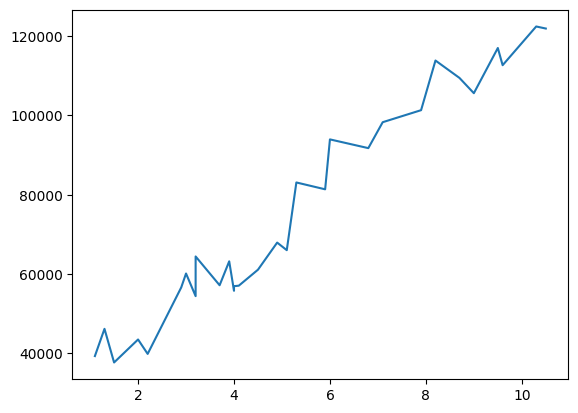

In [15]:
plt.plot(x,y)

In [17]:
#normalising the dataset(getting the mean)
x = np.array(x)
y = np.array(y)

def mean(x):
    return np.sum(x)/len(x)

def variance(x):
    mean_val = mean(x)
    return np.sum((x-mean_val)**2)/len(x)

def norm(x):
    mean_val = mean (x)
    variance_val = variance(x)
    return (x-mean_val)/np.sqrt(variance_val)



In [18]:
x_norm = norm(x)


In [19]:
x_norm

array([-1.51005294, -1.43837321, -1.36669348, -1.18749416, -1.11581443,
       -0.86493538, -0.82909552, -0.75741579, -0.75741579, -0.57821647,
       -0.50653674, -0.47069688, -0.47069688, -0.43485702, -0.29149756,
       -0.1481381 , -0.07645838, -0.00477865,  0.21026054,  0.2461004 ,
        0.53281931,  0.6403389 ,  0.92705781,  1.03457741,  1.21377673,
        1.32129632,  1.50049564,  1.5363355 ,  1.78721455,  1.85889428])

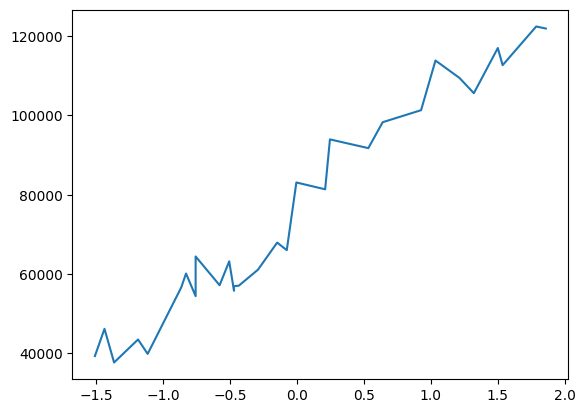

In [20]:
plt.plot(x_norm,y)

In [ ]:
#hyperparameters


In [36]:
import random
#writing the class
class SimpleLR:
    def __init__(self, lr = 0.1, max_iter = 2000, threshold = 1e-6):
        self.lr = lr
        self.max_iter = max_iter
        self.threshold = threshold
        self.weight = random.uniform(-1,1)
        self.bias = random.uniform(-1,1)
    def predict (self,x):
        return self.weight*x + self.bias
    def fit(self, x,y):
        n = len(x)
        loss_history = []
        for i in range(self.max_iter):
            y_pred = self.predict(x)
            errors = y - y_pred
            w_grad = (1/n) * np.sum(errors*x)
            b_grad = (1/n) * np.sum(errors)

            prev_loss = (1/(2*n)) * np.sum(errors**2)

            self.weight += self.lr * w_grad
            self.bias += self.lr * b_grad

            y_pred = self.predict(x)
            errors = y - y_pred
            curr_loss = (1/(2*n)) * np.sum(errors**2)

            if np.abs(curr_loss - prev_loss )< self.threshold:
                break
            loss_history.append (curr_loss)
        return loss_history

    def plot(self, x,y):
        y_pred = self.predict(x)
        plt.plot(x,y, 'o')
        plt.plot(x,y_pred)

In [37]:
model = SimpleLR()


In [38]:
loss_history = model.fit(x_norm ,y)

In [39]:
loss_history

[np.float64(2636674453.741575),
 np.float64(2138677047.9442918),
 np.float64(1735299149.2484932),
 np.float64(1408563051.3048966),
 np.float64(1143906811.9705825),
 np.float64(929535258.1097888),
 np.float64(755894299.4825457),
 np.float64(615245122.9944786),
 np.float64(501319290.03914434),
 np.float64(409039365.3453235),
 np.float64(334292626.34332883),
 np.float64(273747767.7517131),
 np.float64(224706432.2925043),
 np.float64(184982950.5705452),
 np.float64(152806930.3757583),
 np.float64(126744354.01798087),
 np.float64(105633667.1681812),
 np.float64(88534010.8198435),
 np.float64(74683289.17768998),
 np.float64(63464204.647545636),
 np.float64(54376746.17812862),
 np.float64(47015904.817900956),
 np.float64(41053623.316116415),
 np.float64(36224175.29967102),
 np.float64(32312322.406350218),
 np.float64(29143721.56276035),
 np.float64(26577154.879452586),
 np.float64(24498235.865973312),
 np.float64(22814311.46505506),
 np.float64(21450332.700311303),
 np.float64(20345509.900868

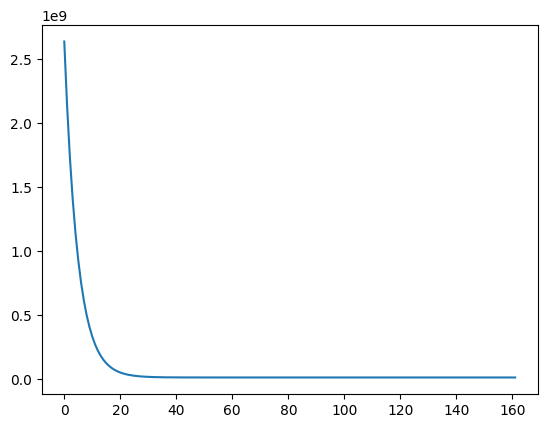

In [40]:
plt.plot(loss_history)

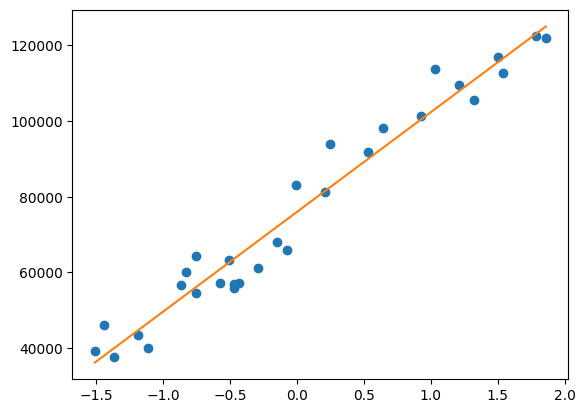

In [42]:
model.plot(x_norm,y)